Note: Notebook to test model generalization to unseen drugs

In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_81140/3599116873.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")


# Select Dataset for Prediction

In [4]:
annotated_variants_df = annotated_control_df

# Filter for EG 

In [5]:
#Keep only rows with EG drugs, cell lines and drop 'MC' source
annotated_variants_df = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Cell_Line'].isin(['HT29', 'A375'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Source'] != 'MC']

In [6]:
len(annotated_variants_df)

84024

# Classification

## Encode Labels

In [7]:
#Define Sensitivity, Neutral and Resistance classes
annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_variants_df.drop(columns=['Hit_class'], inplace=True)

#Encode Classes
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Class'])

In [8]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


In [9]:
annotated_variants_df['Class'].value_counts()

Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

# Define Train and Test

In [33]:
#Train test will be the samples treated with drugs LIN and PIC, and the test set will be the samples treated with SCH
annotated_variants_train = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH'])]
annotated_variants_test = annotated_variants_df[annotated_variants_df['Drug'] == 'LIN']

In [26]:
len(annotated_variants_train), len(annotated_variants_test)

(56016, 28008)

In [27]:
annotated_variants_train['Guide'].nunique(), annotated_variants_test['Guide'].nunique()

(14004, 14004)

In [28]:
annotated_variants_train['Class'].value_counts(), annotated_variants_test['Class'].value_counts()

(Class
 Neutral        55210
 Resistance       540
 Sensitivity      266
 Name: count, dtype: int64,
 Class
 Neutral        27575
 Resistance       248
 Sensitivity      185
 Name: count, dtype: int64)

## Downsample

In [14]:
def stratified_downsampling(df, class_col, random_state=None):
    #Infer majority class + target size (length of the second largest class)
    class_counts = df[class_col].value_counts()
    majority_class = class_counts.idxmax()
    target_size = class_counts.nlargest(2).iloc[-1]

    #Separate majority class and other classes
    major_df = df[df[class_col] == majority_class]
    other_df = df[df[class_col] != majority_class]

    # If majority already not bigger than target, nothing to do
    if len(major_df) <= target_size:
        return df.copy()
    
    #Compute distribution of the majority df across Cell_Line and Gene
    major_distribution = (
        major_df
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    major_distribution['Proportion'] = major_distribution['Count'] / major_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene group
    major_distribution['Target'] = np.floor(major_distribution['Proportion'] * target_size).astype(int)

    # Adjust target to ensure total matches target size 
    # i.e., distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_size - major_distribution['Target'].sum()
    if difference > 0:
        fractional_parts = major_distribution['Proportion'] * target_size - major_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        major_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_major_dfs= []
    for _, row in major_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']

        subset = major_df[(major_df['Cell_Line'] == cell_line) & (major_df['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case it is a very small group - but can lead to less samples than target_size overall
            downsampled_major_dfs.append(subset.sample(n=n_sampled, random_state=random_state))
    
    #Keep the indices until after the Top up step
    downsampled_majority_class_df = pd.concat(downsampled_major_dfs, axis=0)

    #Top up if needed (if very small groups caused total to be less than target_size)
    current_size = len(downsampled_majority_class_df)
    missing = target_size - current_size

    if missing>0: #ask supervisor if this is really needed
        remaining_samples = major_df.loc[~major_df.index.isin(downsampled_majority_class_df.index)]
        assert not remaining_samples.empty, ("Logic error: remaining_samples is empty but target_size not reached.")
        extra_n= min(missing, len(remaining_samples))
        extra_samples = remaining_samples.sample(n=extra_n, random_state=random_state)

        #Random subsample from the remaining samples now
        downsampled_majority_class_df = pd.concat([downsampled_majority_class_df, extra_samples], axis=0)

    # Reset index only at the end
    downsampled_majority_class_df = downsampled_majority_class_df.reset_index(drop=True)

    #Combine downsampled majority class with other classes
    balanced_df = pd.concat([downsampled_majority_class_df, other_df], ignore_index=True)

    return balanced_df

## Modeling

In [15]:
#Define meta data columns to drop
meta_cols=[
    'Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Source', 'Target Transcript ID', 'uniprot_accession',
    'RefSeq match transcript (MANE Select)', 'Amino Acid Edits', 'aa_change', 'pocket_id', 'Class'
]

In [16]:
def train_test_once_no_cv(train_df, test_df, model, meta_cols, le, stratified_downsampling, class_col, random_state_for_downsampling):
    
    #Downsample training and test set
    train_df_balanced = stratified_downsampling(train_df, class_col = class_col, random_state=random_state_for_downsampling)
    test_df_balanced = stratified_downsampling(test_df, class_col = class_col, random_state=1)


    #Print class distribution after downsampling
    print("Train Class distribution after downsampling:")
    print(train_df_balanced['Class'].value_counts())

    print("\nTest Class distribution after downsampling:")
    print(test_df_balanced['Class'].value_counts())

    #Split features and labels
    X_train = train_df_balanced.drop(columns=meta_cols + ["Class_encoded"])
    y_train = train_df_balanced["Class_encoded"]

    X_test = test_df_balanced.drop(columns=meta_cols + ["Class_encoded"])
    y_test = test_df_balanced["Class_encoded"]

    #Train model
    model.fit(X_train, y_train)

    #Predict on test set
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)

    #Metrics
    class_names = list(le.classes_)
    metrics = {}

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

    metrics['accuracy'] = report['accuracy']

    for avg_key in ['macro avg', 'weighted avg']:
        metrics[f'precision_{avg_key}'] = report[avg_key]['precision']
        metrics[f'recall_{avg_key}'] = report[avg_key]['recall']
        metrics[f'f1_{avg_key}'] = report[avg_key]['f1-score']

    for cname in class_names:
        metrics[f'precision_{cname}'] = report[cname]['precision']
        metrics[f'recall_{cname}'] = report[cname]['recall']
        metrics[f'f1_{cname}'] = report[cname]['f1-score']

    
    n_classes = len(class_names)

    #ROC AUC
    metrics['roc_auc_weighted'] = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
    metrics['roc_auc_macro'] = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')

    #PR AUC
    metrics['pr_auc_weighted'] = average_precision_score(y_test, probs, average='weighted')
    metrics['pr_auc_macro'] = average_precision_score(y_test, probs, average='macro')

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

    return metrics, cm, y_test.values, y_pred, probs

### Define Model and Cross-Validation

In [17]:
optimized_params = {'n_estimators': 473,
                    'max_depth': 8,
                    'learning_rate': 0.014757846958987166,
                    'subsample': 0.9074779169306355,
                    'colsample_bytree': 0.5480484893807359,
                    'min_child_weight': 1,
                    'reg_alpha': 0.0004937375718649116,
                    'reg_lambda': 0.000319094062330884,
                    'gamma': 0.6244886434704836}


#Define optimized XGBClassifier with Optuna parameters  
xgb_classifier_optimized = XGBClassifier(
    **optimized_params                   
)

### Run Model

In [34]:
# Run multiple times to get average performance across different downsamplings
n_runs=10

all_metrics, all_cms = [], []
all_y_true_runs, all_y_pred_runs, all_probs_runs = [], [], []
all_shap_values_runs = []
all_X_test_runs, all_meta_X_test_runs = [], []

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")

    metrics, cm, y_true, y_pred, probs = train_test_once_no_cv(
        train_df=annotated_variants_train,
        test_df=annotated_variants_test,
        model=xgb_classifier_optimized,
        meta_cols=meta_cols,
        le=le,
        stratified_downsampling=stratified_downsampling,
        class_col="Class",
        random_state_for_downsampling=i
    )

    all_metrics.append(metrics)
    all_cms.append(cm)
    all_y_true_runs.append(y_true)
    all_y_pred_runs.append(y_pred)
    all_probs_runs.append(probs)

    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)
  
# === Aggregate metrics across runs ===
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std  = np.std(np.array(all_cms, dtype=float), axis=0)


# Reorder confusion matrix
desired_order = ["Sensitivity", "Neutral", "Resistance"]

# Map to label encoder indices
reorder_idx = [list(le.classes_).index(c) for c in desired_order]

# Reorder rows and columns
cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

# Update class_names for correct axis labels
class_names_reordered = desired_order

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Train Class distribution after downsampling:
Class
Neutral        495
Resistance     495
Sensitivity    359
Name: count, dtype: int64

Test Class distribution after downsampling:
Class
Neutral        293
Resistance     293
Sensitivity     92
Name: count, dtype: int64
Metrics: {'accuracy': 0.6622418879056047, 'precision_macro avg': 0.6690431603352952, 'recall_macro avg': 0.6251422070534698, 'f1_macro avg': 0.6252462912644989, 'precision_weighted avg': 0.6969232122931039, 'recall_weighted avg': 0.6622418879056047, 'f1_weighted avg': 0.6520351948591708, 'precision_Neutral': 0.611904761904762, 'recall_Neutral': 0.8771331058020477, 'f1_Neutral': 0.7208976157082749, 'precision_Resistance': 0.8202247191011236, 'recall_Resistance': 0.49829351535836175, 'f1_Resistance': 0.6199575371549894, 'precision_Sensitivity': 0.575, 'recall_Sensitivity': 0.5, 'f1_Sensitivity': 0.5348837209302325, 'roc_auc_weighted': np.float64(0.7580923772835337), 'roc_auc_macro': np.float64(0.77209671171

In [19]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # === Reorder ===
    desired_order = ["Sensitivity", "Neutral", "Resistance"]
    reorder_idx = [list(class_names).index(c) for c in desired_order]

    cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
    cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

    class_names = desired_order

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   
            std_val = int(cm_std[i, j])       
            combined[i, j] = f"{mean_val}±{std_val}"


    plt.figure(figsize=(2.5, 2.5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2 + 0.105, height + 0.005,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2 + 0.105, height + 0.005,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=9)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    plt.show()

    return summary, cm_mean, cm_std


=== Metrics Summary (mean ± std) ===
accuracy            : 0.669 ± 0.007
roc_auc_weighted    : 0.763 ± 0.007
roc_auc_macro       : 0.774 ± 0.005
pr_auc_weighted     : 0.674 ± 0.008
pr_auc_macro        : 0.643 ± 0.009
precision_macro avg : 0.685 ± 0.015
recall_macro avg    : 0.633 ± 0.007
f1_macro avg        : 0.637 ± 0.007
precision_weighted avg: 0.704 ± 0.012
recall_weighted avg : 0.669 ± 0.007
f1_weighted avg     : 0.659 ± 0.007

=== Class-wise Metrics (mean ± std) ===
Neutral    precision : 0.613 ± 0.007
Neutral    recall    : 0.878 ± 0.022
Neutral    f1        : 0.722 ± 0.008
Resistance precision : 0.820 ± 0.021
Resistance recall    : 0.509 ± 0.015
Resistance f1        : 0.628 ± 0.010
Sensitivity precision : 0.620 ± 0.034
Sensitivity recall    : 0.514 ± 0.015
Sensitivity f1        : 0.562 ± 0.014


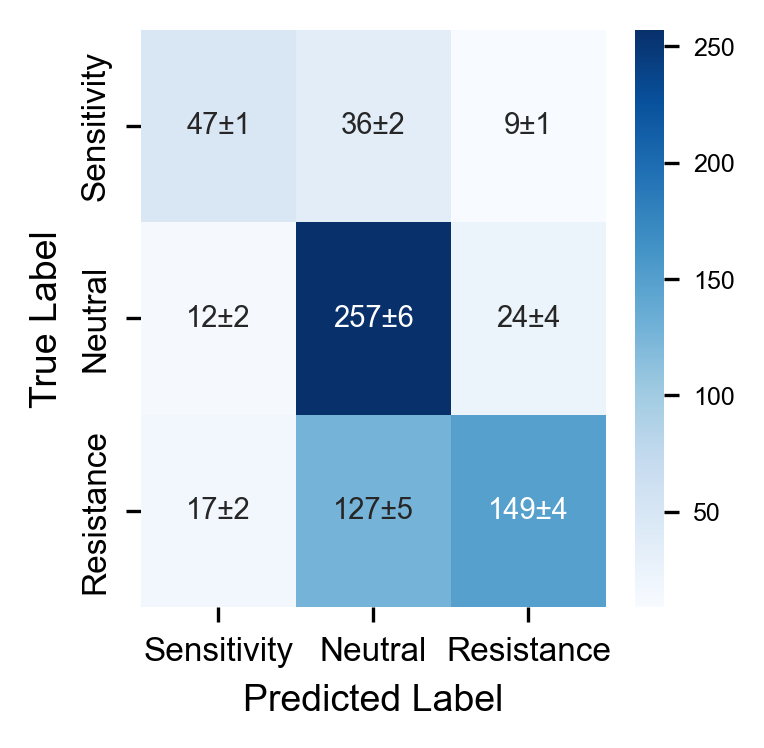

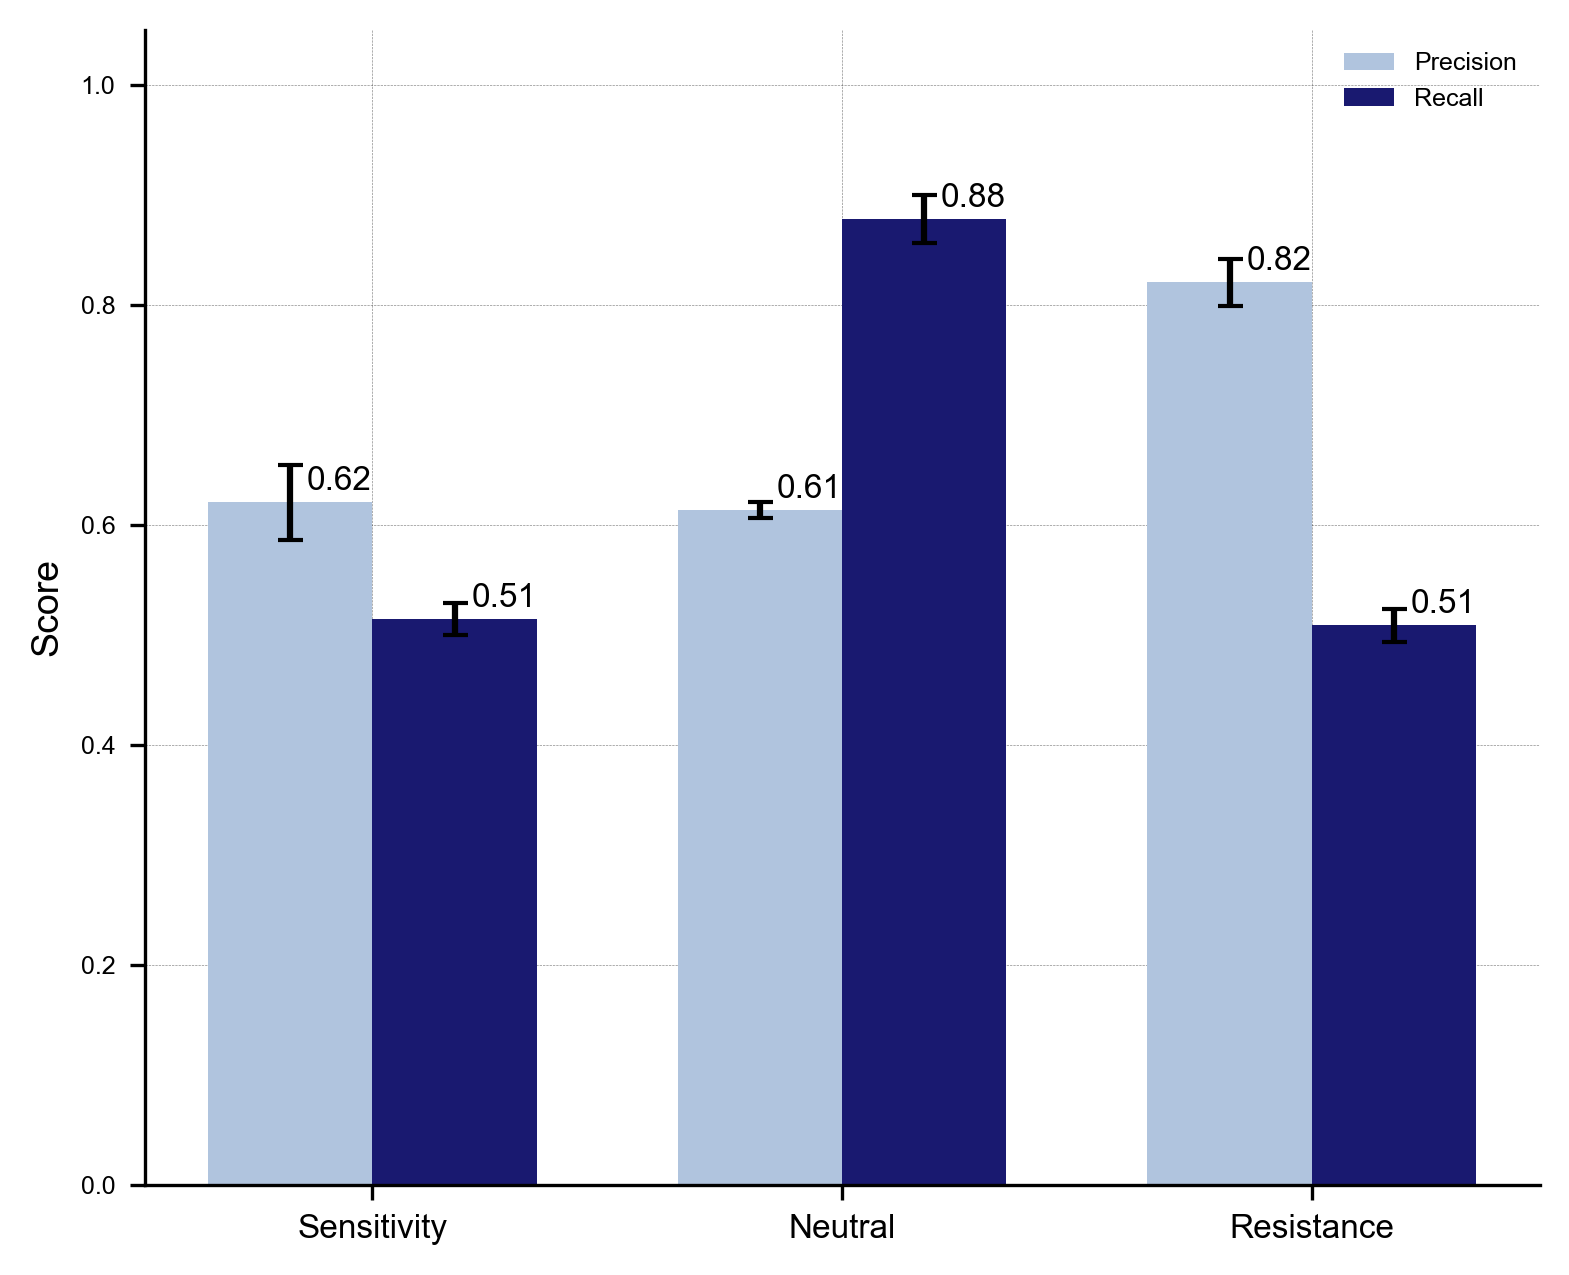

In [35]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

### F1 Plot

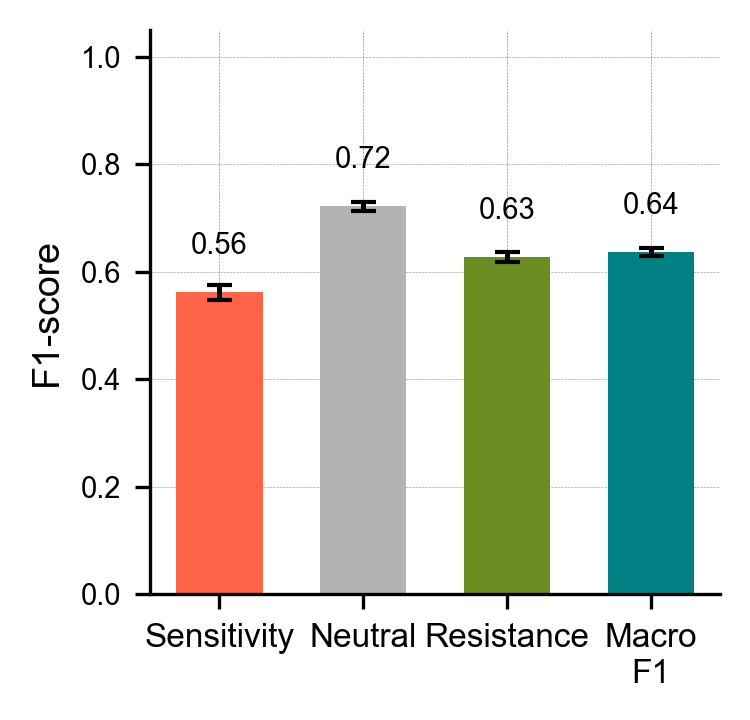

In [36]:
# Define your desired class order (using the metric keys used to index all metrics )
class_order = ["Sensitivity", "Neutral", "Resistance", "macro avg"]

# Display labels for the x-axis
display_labels = ["Sensitivity", "Neutral", "Resistance", "Macro\nF1"]

# Compute mean and std in that order
f1_means = [np.mean([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]
f1_stds  = [np.std([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab", "teal"]

x = np.arange(len(display_labels))
plt.figure(figsize=(2.6,2.5))

bars = plt.bar(x, f1_means, yerr=f1_stds, capsize=3, color=colors_bar, width = 0.6, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.06, f"{height:.2f}", ha='center', va='bottom', fontsize=7)

plt.xticks(x, display_labels, fontsize=8)
plt.ylabel("F1-score", fontsize=9)
plt.yticks(fontsize=7)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#Save the dataset used for the F1 plot
f1_results_to_plot_df = pd.DataFrame({
    "Class": class_order,
    "F1_mean": f1_means,
    "F1_std": f1_stds
})

f1_results_to_plot_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/f1_scores_across_10_runs_plot_benchmark4_train_PIC-LIN.csv", index=False)

### PR Curve

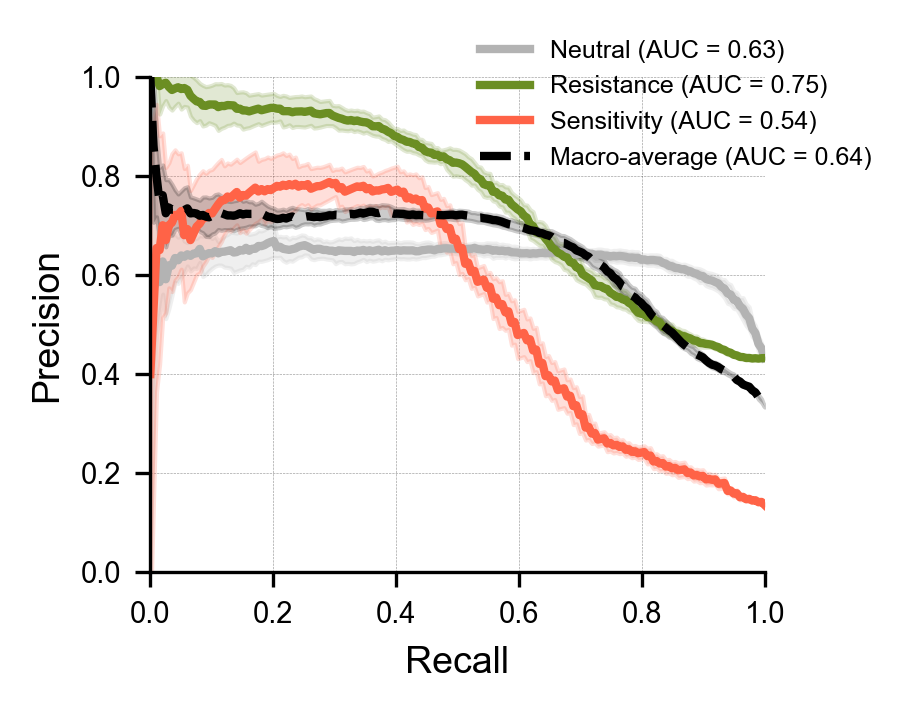

In [37]:
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(3,2.5))

for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(recall_grid, mean_precision, color=colors[i], lw=2, label=f"{class_name} (AUC = {mean_auc:.2f})")
    plt.fill_between(recall_grid, mean_precision - std_precision, mean_precision + std_precision,
                     color=colors[i], alpha=0.2)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)


plt.plot(recall_grid, mean_macro, color='black', lw=2, linestyle='--', label=f"Macro-average (AUC = {mean_auc_macro:.2f})")
plt.fill_between(recall_grid, mean_macro - std_macro, mean_macro + std_macro, color='black', alpha=0.2)

plt.xlabel("Recall", fontsize=9)
plt.xticks(fontsize=7)
plt.ylabel("Precision", fontsize=9)
plt.yticks(fontsize=7)
plt.legend(fontsize=6, loc="upper left", frameon=False, bbox_to_anchor=(0.5, 1.12))
#plt.legend(fontsize=7, loc="lower left", frameon=False, bbox_to_anchor=(0.13, 0.08))
plt.grid(alpha=0.4)
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()